# 5CS037 Final Portfolio Project - Task 1: Classification

## Global Life-Expectancy Bracket Prediction
### UN SDG 3: Good Health and Well-being

**Student ID:** 2507008
**Module:** Concepts and Technologies of AI
**Submission Date:** 10 Feb 2026

---

### Task Overview
This notebook implements the **classification** half of the portfolio: an
end-to-end pipeline that predicts whether a country-year falls in the **high**
(>= 70 yrs) or **low** (< 70 yrs) life-expectancy bracket, aligned with
**UN SDG 3 - Good Health and Well-being**.

The shared setup cells (imports, configuration and helper/evaluation functions)
below are identical to those in `Task2.ipynb`, so this notebook runs on its own
as long as it sits beside `Data from Google Cloud.csv`.

---


In [ ]:
# =============================================================================
# IMPORTS AND CONFIGURATION
# =============================================================================
# Core libraries for data manipulation and numerical operations
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn: Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.impute import SimpleImputer

# Scikit-learn: Classification Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Scikit-learn: Regression Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

# Scikit-learn: Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve,
    mean_absolute_error, mean_squared_error, r2_score
)

# Scikit-learn: Feature Selection
from sklearn.feature_selection import (
    SelectKBest, f_classif, f_regression,
    RFE, mutual_info_classif, mutual_info_regression,
    VarianceThreshold
)

# Neural Network (using sklearn's MLPClassifier and MLPRegressor)
from sklearn.neural_network import MLPClassifier, MLPRegressor

# Utility libraries
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.float_format', '{:.4f}'.format)

# Random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("All libraries imported successfully!")
print(f"Random state set to: {RANDOM_STATE}")


All libraries imported successfully!
Random state set to: 42


In [ ]:
# =============================================================================
# HELPER FUNCTIONS
# =============================================================================

def load_and_describe_dataset(filepath, dataset_name, description):
    """Load a dataset and display comprehensive information about it."""
    print(f"\n{'='*80}")
    print(f"DATASET: {dataset_name}")
    print(f"{'='*80}")
    print(f"\nDescription: {description}")

    df = pd.read_csv(filepath)

    print(f"\nDataset Shape: {df.shape[0]} rows x {df.shape[1]} columns")
    print(f"\nColumn Information:")
    print("-" * 60)

    for col in df.columns:
        dtype = df[col].dtype
        non_null = df[col].notna().sum()
        null_pct = (df[col].isna().sum() / len(df)) * 100
        print(f"  - {col}: {dtype} | Non-Null: {non_null} | Missing: {null_pct:.2f}%")

    return df


def display_summary_statistics(df, title="Summary Statistics"):
    """Display comprehensive summary statistics for a DataFrame."""
    print(f"\n{'='*80}")
    print(f"{title}")
    print(f"{'='*80}")

    numerical_cols = df.select_dtypes(include=[np.number]).columns
    if len(numerical_cols) > 0:
        print("\nNumerical Features Statistics:")
        display(df[numerical_cols].describe().round(4))

    categorical_cols = df.select_dtypes(include=['object', 'category']).columns
    if len(categorical_cols) > 0:
        print("\nCategorical Features:")
        for col in categorical_cols:
            print(f"\n  {col}:")
            print(df[col].value_counts().head(10))


def check_data_quality(df):
    """Assess data quality: missing values, duplicates, and data types."""
    print(f"\n{'='*80}")
    print("DATA QUALITY ASSESSMENT")
    print(f"{'='*80}")

    quality_report = {}

    missing = df.isnull().sum()
    missing_pct = (missing / len(df)) * 100
    quality_report['missing_values'] = missing[missing > 0]

    print("\nMissing Values Analysis:")
    if missing.sum() > 0:
        missing_df = pd.DataFrame({
            'Missing Count': missing[missing > 0],
            'Missing %': missing_pct[missing_pct > 0]
        }).sort_values('Missing %', ascending=False)
        display(missing_df)
    else:
        print("  No missing values found!")

    duplicates = df.duplicated().sum()
    quality_report['duplicates'] = duplicates
    print(f"\nDuplicate Rows: {duplicates} ({(duplicates/len(df))*100:.2f}%)")

    print("\nData Types Distribution:")
    dtype_counts = df.dtypes.value_counts()
    for dtype, count in dtype_counts.items():
        print(f"  - {dtype}: {count} columns")

    return quality_report


def plot_missing_values(df, title="Missing Values Heatmap"):
    """Create a heatmap visualization of missing values."""
    fig, ax = plt.subplots(figsize=(12, 6))
    missing_matrix = df.isnull()
    sns.heatmap(missing_matrix.T, cbar=True, cmap='YlOrRd',
                yticklabels=df.columns, ax=ax)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Sample Index')
    ax.set_ylabel('Features')
    plt.tight_layout()
    plt.show()


def plot_distribution(df, columns, title="Feature Distributions"):
    """Plot distribution of numerical features using histograms and KDE."""
    n_cols = min(3, len(columns))
    n_rows = (len(columns) + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
    axes = np.array(axes).flatten() if len(columns) > 1 else [axes]

    for i, col in enumerate(columns):
        if i < len(axes):
            ax = axes[i]
            data = df[col].dropna()
            sns.histplot(data, kde=True, ax=ax, color='steelblue', alpha=0.7)
            mean_val = data.mean()
            median_val = data.median()
            ax.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
            ax.axvline(median_val, color='green', linestyle='-.', label=f'Median: {median_val:.2f}')
            ax.set_title(f'{col}', fontsize=11, fontweight='bold')
            ax.legend(fontsize=8)

    for j in range(len(columns), len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(title, fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()


def plot_correlation_matrix(df, title="Correlation Matrix"):
    """Plot correlation matrix heatmap."""
    numerical_df = df.select_dtypes(include=[np.number])
    corr_matrix = numerical_df.corr()
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
                cmap='RdBu_r', center=0, square=True,
                linewidths=0.5, ax=ax, annot_kws={'size': 8})
    ax.set_title(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    return corr_matrix


def plot_boxplots(df, columns, title="Box Plots - Outlier Detection"):
    """Create box plots for outlier detection."""
    n_cols = min(4, len(columns))
    n_rows = (len(columns) + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 4*n_rows))
    axes = np.array(axes).flatten() if len(columns) > 1 else [axes]

    for i, col in enumerate(columns):
        if i < len(axes):
            ax = axes[i]
            sns.boxplot(y=df[col], ax=ax, color='lightblue')
            ax.set_title(f'{col}', fontsize=10, fontweight='bold')

    for j in range(len(columns), len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(title, fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()


print("Helper functions defined successfully!")


Helper functions defined successfully!


In [ ]:
# =============================================================================
# MODEL BUILDING AND EVALUATION FUNCTIONS
# =============================================================================

def evaluate_classification_model(model, X_train, X_test, y_train, y_test, model_name="Model"):
    """Comprehensive evaluation of a classification model."""
    print(f"\n{'='*60}")
    print(f"EVALUATION: {model_name}")
    print(f"{'='*60}")

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    metrics = {
        'model_name': model_name,
        'train_accuracy': accuracy_score(y_train, y_train_pred),
        'test_accuracy': accuracy_score(y_test, y_test_pred),
        'precision': precision_score(y_test, y_test_pred, average='weighted'),
        'recall': recall_score(y_test, y_test_pred, average='weighted'),
        'f1_score': f1_score(y_test, y_test_pred, average='weighted')
    }

    print(f"\nPerformance Metrics:")
    print(f"  - Training Accuracy: {metrics['train_accuracy']:.4f}")
    print(f"  - Test Accuracy:     {metrics['test_accuracy']:.4f}")
    print(f"  - Precision:         {metrics['precision']:.4f}")
    print(f"  - Recall:            {metrics['recall']:.4f}")
    print(f"  - F1-Score:          {metrics['f1_score']:.4f}")

    print(f"\nClassification Report:")
    print(classification_report(y_test, y_test_pred))

    fig, ax = plt.subplots(figsize=(8, 6))
    cm = confusion_matrix(y_test, y_test_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(f'Confusion Matrix - {model_name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    plt.tight_layout()
    plt.show()

    return metrics


def evaluate_regression_model(model, X_train, X_test, y_train, y_test, model_name="Model"):
    """Comprehensive evaluation of a regression model."""
    print(f"\n{'='*60}")
    print(f"EVALUATION: {model_name}")
    print(f"{'='*60}")

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    metrics = {
        'model_name': model_name,
        'train_mae': mean_absolute_error(y_train, y_train_pred),
        'test_mae': mean_absolute_error(y_test, y_test_pred),
        'train_mse': mean_squared_error(y_train, y_train_pred),
        'test_mse': mean_squared_error(y_test, y_test_pred),
        'train_rmse': np.sqrt(mean_squared_error(y_train, y_train_pred)),
        'test_rmse': np.sqrt(mean_squared_error(y_test, y_test_pred)),
        'train_r2': r2_score(y_train, y_train_pred),
        'test_r2': r2_score(y_test, y_test_pred)
    }

    print(f"\nPerformance Metrics:")
    print(f"  Training Set:")
    print(f"    - MAE:  {metrics['train_mae']:.4f}")
    print(f"    - MSE:  {metrics['train_mse']:.4f}")
    print(f"    - RMSE: {metrics['train_rmse']:.4f}")
    print(f"    - R2:   {metrics['train_r2']:.4f}")
    print(f"  Test Set:")
    print(f"    - MAE:  {metrics['test_mae']:.4f}")
    print(f"    - MSE:  {metrics['test_mse']:.4f}")
    print(f"    - RMSE: {metrics['test_rmse']:.4f}")
    print(f"    - R2:   {metrics['test_r2']:.4f}")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].scatter(y_test, y_test_pred, alpha=0.5, color='steelblue')
    axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    axes[0].set_xlabel('Actual Values')
    axes[0].set_ylabel('Predicted Values')
    axes[0].set_title(f'{model_name}: Actual vs Predicted', fontweight='bold')

    residuals = y_test - y_test_pred
    axes[1].hist(residuals, bins=30, color='steelblue', alpha=0.7, edgecolor='black')
    axes[1].axvline(0, color='red', linestyle='--', lw=2)
    axes[1].set_xlabel('Residuals')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title(f'{model_name}: Residuals Distribution', fontweight='bold')

    plt.tight_layout()
    plt.show()

    return metrics


def perform_cross_validation(model, X, y, cv=5, scoring='accuracy', model_name="Model"):
    """Perform k-fold cross-validation and display results."""
    print(f"\n{'='*60}")
    print(f"CROSS-VALIDATION: {model_name}")
    print(f"{'='*60}")

    cv_scores = cross_val_score(model, X, y, cv=cv, scoring=scoring)
    results = {
        'model_name': model_name,
        'cv_scores': cv_scores,
        'mean_score': cv_scores.mean(),
        'std_score': cv_scores.std()
    }
    print(f"\n{cv}-Fold Cross-Validation Results:")
    print(f"  - Scores: {[f'{s:.4f}' for s in cv_scores]}")
    print(f"  - Mean:   {results['mean_score']:.4f} (+/- {results['std_score']:.4f})")
    return results


def hyperparameter_tuning(model, param_grid, X_train, y_train, cv=5,
                          scoring='accuracy', search_type='grid', n_iter=50):
    """Perform hyperparameter tuning using GridSearchCV or RandomizedSearchCV."""
    print(f"\n{'='*60}")
    print(f"HYPERPARAMETER TUNING ({search_type.upper()} SEARCH)")
    print(f"{'='*60}")

    if search_type == 'grid':
        search = GridSearchCV(model, param_grid, cv=cv, scoring=scoring,
                              n_jobs=-1, verbose=1, return_train_score=True)
    else:
        search = RandomizedSearchCV(model, param_grid, n_iter=n_iter, cv=cv,
                                    scoring=scoring, n_jobs=-1, verbose=1,
                                    random_state=RANDOM_STATE, return_train_score=True)

    search.fit(X_train, y_train)

    print(f"\nBest Parameters:")
    for param, value in search.best_params_.items():
        print(f"  - {param}: {value}")
    print(f"\nBest CV Score: {search.best_score_:.4f}")

    return search.best_estimator_, search.best_params_, search.best_score_


def perform_feature_selection(X, y, method='rfe', n_features=10, model=None, task='classification'):
    """Perform feature selection using various methods."""
    print(f"\n{'='*60}")
    print(f"FEATURE SELECTION: {method.upper()}")
    print(f"{'='*60}")

    feature_names = X.columns.tolist()

    if method == 'rfe':
        if model is None:
            if task == 'classification':
                model = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
            else:
                model = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE)
        selector = RFE(model, n_features_to_select=n_features, step=1)
        selector.fit(X, y)
        selected_mask = selector.support_
        rankings = selector.ranking_
        feature_importance = pd.DataFrame({
            'Feature': feature_names, 'Selected': selected_mask, 'Ranking': rankings
        }).sort_values('Ranking')

    elif method == 'selectkbest':
        score_func = f_classif if task == 'classification' else f_regression
        selector = SelectKBest(score_func=score_func, k=n_features)
        selector.fit(X, y)
        selected_mask = selector.get_support()
        scores = selector.scores_
        feature_importance = pd.DataFrame({
            'Feature': feature_names, 'Selected': selected_mask, 'Score': scores
        }).sort_values('Score', ascending=False)

    elif method == 'mutual_info':
        if task == 'classification':
            mi_scores = mutual_info_classif(X, y, random_state=RANDOM_STATE)
        else:
            mi_scores = mutual_info_regression(X, y, random_state=RANDOM_STATE)
        feature_importance = pd.DataFrame({
            'Feature': feature_names, 'MI_Score': mi_scores
        }).sort_values('MI_Score', ascending=False)
        selected_features = feature_importance.head(n_features)['Feature'].tolist()
        selected_mask = [f in selected_features for f in feature_names]
        feature_importance['Selected'] = selected_mask
        selector = None

    selected_features = [f for f, s in zip(feature_names, selected_mask) if s]

    print(f"\nSelected Features ({len(selected_features)}):")
    for i, feat in enumerate(selected_features, 1):
        print(f"  {i}. {feat}")

    fig, ax = plt.subplots(figsize=(10, 6))
    if method in ['selectkbest', 'mutual_info']:
        score_col = 'Score' if method == 'selectkbest' else 'MI_Score'
        top_features = feature_importance.head(15)
        colors = ['green' if s else 'lightgray' for s in top_features['Selected']]
        ax.barh(top_features['Feature'], top_features[score_col], color=colors)
        ax.set_xlabel('Score')
    else:
        top_features = feature_importance.head(15)
        colors = ['green' if s else 'lightgray' for s in top_features['Selected']]
        ax.barh(top_features['Feature'], top_features['Ranking'], color=colors)
        ax.set_xlabel('Ranking (lower is better)')
    ax.set_title(f'Feature Selection: {method.upper()}', fontweight='bold')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

    return selected_features, selector, feature_importance


print("Model building and evaluation functions defined successfully!")


Model building and evaluation functions defined successfully!


# ============================================================================
# PART A: CLASSIFICATION TASK
# ============================================================================

## Global Life-Expectancy Bracket Prediction
### UN SDG 3: Good Health and Well-being

---

### Dataset Description

**Dataset Name:** Global Health, Mortality and Population since 2000 (World Bank indicators)
**Source:** Kaggle (Shreyansh Dangi, compiled from World Bank / Google Cloud public data)
**Access Method:** Downloaded from Kaggle public datasets

**UNSDG Alignment:** This dataset aligns with **UN Sustainable Development Goal 3 (SDG 3): Good Health and Well-being**. Classifying whether a country-year sits in a high or low life-expectancy bracket, from its mortality, fertility and health-system indicators, supports evidence-based public-health targeting.

**Target Variable:** `Longevity_Class` (Binary, engineered from life expectancy at birth). A country-year is labelled **High** when life expectancy is at or above the 70-year global benchmark and **Low** otherwise.

**Features (per country-year):**
1. `infant_mortality` - Mortality rate, infant (per 1,000 live births)
2. `under5_mortality` - Mortality rate, under-5 (per 1,000 live births)
3. `adult_mortality_male` - Mortality rate, adult, male (per 1,000)
4. `adult_mortality_female` - Mortality rate, adult, female (per 1,000)
5. `birth_rate` - Birth rate, crude (per 1,000 people)
6. `fertility_rate` - Fertility rate, total (births per woman)
7. `adolescent_fertility` - Adolescent fertility rate (per 1,000 women 15-19)
8. `health_expenditure_gdp` - Current health expenditure (% of GDP)
9. `measles_immunization` - Immunization, measles (% of children 12-23 months)
10. `basic_sanitation` - People using at least basic sanitation services (% of population)

**Questions this dataset can answer:**
1. Which health and demographic indicators most strongly separate high- from low-longevity populations?
2. Can the life-expectancy bracket of a country-year be predicted from a compact panel of indicators?
3. Do mortality measures dominate, or do health-system and sanitation indicators carry independent signal?

---


In [ ]:
# =============================================================================
# TASK 1: LOAD AND RESHAPE GLOBAL HEALTH DATASET
# =============================================================================

print("="*80)
print("LOADING GLOBAL HEALTH DATASET")
print("="*80)

raw_health = pd.read_csv('Data from Google Cloud.csv', encoding='utf-8-sig')
raw_health = raw_health.rename(columns={raw_health.columns[0]: 'Series'})
print(f"\nRaw (wide) shape: {raw_health.shape}")

# The file is wide: one row per (indicator, country) with a column per year.
# Reshape to long, then pivot so each row is a single (Country, Year) observation.
year_cols = [c for c in raw_health.columns if c.isdigit()]
long_health = raw_health.melt(id_vars=['Series', 'Country Name'], value_vars=year_cols,
                              var_name='Year', value_name='Value')
long_health['Value'] = pd.to_numeric(long_health['Value'], errors='coerce')
long_health['Year'] = long_health['Year'].astype(int)
wide_health = long_health.pivot_table(index=['Country Name', 'Year'],
                                      columns='Series', values='Value').reset_index()

target_series = 'Life expectancy at birth, total (years)'
feature_map = {
    'Mortality rate, infant (per 1,000 live births)': 'infant_mortality',
    'Mortality rate, under-5 (per 1,000 live births)': 'under5_mortality',
    'Mortality rate, adult, male (per 1,000 male adults)': 'adult_mortality_male',
    'Mortality rate, adult, female (per 1,000 female adults)': 'adult_mortality_female',
    'Birth rate, crude (per 1,000 people)': 'birth_rate',
    'Fertility rate, total (births per woman)': 'fertility_rate',
    'Adolescent fertility rate (births per 1,000 women ages 15-19)': 'adolescent_fertility',
    'Current health expenditure (% of GDP)': 'health_expenditure_gdp',
    'Immunization, measles (% of children ages 12-23 months)': 'measles_immunization',
    'People using at least basic sanitation services (% of population)': 'basic_sanitation',
}

cols_needed = ['Country Name', 'Year', target_series] + list(feature_map.keys())
df_health = wide_health[cols_needed].rename(columns=feature_map)
df_health = df_health.rename(columns={target_series: 'life_expectancy'})
df_health = df_health.dropna().reset_index(drop=True)

# Engineer the binary target: High vs Low life-expectancy bracket (70-year benchmark).
LIFE_EXP_BENCHMARK = 70.0
df_health['Longevity_Class'] = (df_health['life_expectancy'] >= LIFE_EXP_BENCHMARK).astype(int)

# Predictors: the ten indicators + Year (drop the raw continuous life_expectancy
# that defines the label, and the Country Name identifier).
feature_cols_health = list(feature_map.values()) + ['Year']
df_classification = df_health[feature_cols_health + ['Longevity_Class']].copy()

print(f"\nReshaped country-year dataset: {df_health.shape}")
print(f"Countries: {df_health['Country Name'].nunique()} | Years: {df_health['Year'].min()}-{df_health['Year'].max()}")
print(f"\nClassification dataset ready: {df_classification.shape[0]} rows x {df_classification.shape[1]} columns")
print(f"Target: Longevity_Class (1 = High >= {LIFE_EXP_BENCHMARK} yrs, 0 = Low)")
print(f"\nFirst 10 rows:")
display(df_classification.head(10))


LOADING GLOBAL HEALTH DATASET

Raw (wide) shape: (23870, 26)

Reshaped country-year dataset: (4235, 14)
Countries: 192 | Years: 2000-2022

Classification dataset ready: 4235 rows x 12 columns
Target: Longevity_Class (1 = High >= 70.0 yrs, 0 = Low)

First 10 rows:


Series,infant_mortality,under5_mortality,adult_mortality_male,adult_mortality_female,birth_rate,fertility_rate,adolescent_fertility,health_expenditure_gdp,measles_immunization,basic_sanitation,Year,Longevity_Class
0,103.8000,123.1000,334.5450,284.7430,47.4880,7.3200,150.1610,9.4434,35.0000,22.5413,2002,0
1,100.6000,118.7000,324.3270,272.5890,47.0560,7.1740,143.7500,8.9413,39.0000,24.1003,2003,0
2,97.2000,114.2000,315.2660,266.2960,46.4920,7.0180,136.9300,9.8085,48.0000,25.6662,2004,0
3,93.7000,109.7000,312.8520,261.0400,44.9520,6.8580,130.8380,9.9483,50.0000,27.2392,2005,0
4,90.1000,105.1000,317.4570,255.8420,44.0870,6.6860,121.6350,10.6228,53.0000,28.8123,2006,0
5,86.7000,100.7000,322.1590,249.2080,43.8310,6.5080,117.7540,9.9047,55.0000,30.4665,2007,0
6,83.3000,96.3000,308.4690,242.4170,42.5380,6.3920,118.9790,10.2565,59.0000,32.1287,2008,0
7,80.0000,92.2000,295.6610,238.0150,42.1620,6.2950,109.6550,9.8185,60.0000,33.7990,2009,0
8,76.9000,88.3000,291.2060,232.8730,41.7590,6.1950,105.6480,8.5697,62.0000,35.4775,2010,0
9,74.0000,84.6000,285.3040,227.0390,40.9730,6.0940,101.6590,8.5619,64.0000,37.1646,2011,0



DATA QUALITY ASSESSMENT

Missing Values Analysis:
  No missing values found!

Duplicate Rows: 0 (0.00%)

Data Types Distribution:
  - float64: 10 columns
  - int64: 2 columns


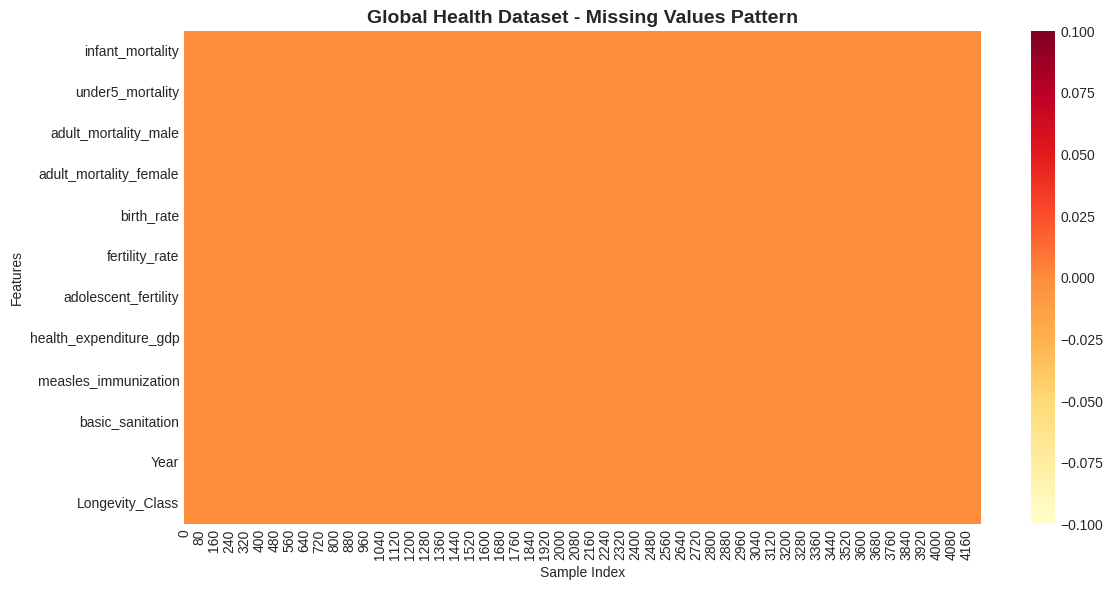

In [ ]:
# =============================================================================
# TASK 1.1: DATA QUALITY ASSESSMENT (Classification)
# =============================================================================

quality_report_clf = check_data_quality(df_classification)
plot_missing_values(df_classification, title="Global Health Dataset - Missing Values Pattern")



Global Health Dataset - Summary Statistics

Numerical Features Statistics:


Series,infant_mortality,under5_mortality,adult_mortality_male,adult_mortality_female,birth_rate,fertility_rate,adolescent_fertility,health_expenditure_gdp,measles_immunization,basic_sanitation,Year,Longevity_Class
count,4235.0000,4235.0000,4235.0000,4235.0000,4235.0000,4235.0000,4235.0000,4235.0000,4235.0000,4235.0000,4235.0000,4235.0000
mean,26.8701,37.3734,221.7535,148.6516,22.1763,2.9217,54.1662,6.2262,85.9783,72.2966,2010.8961,0.5695
std,24.8887,40.7808,115.8903,105.2438,11.0330,1.5041,44.1166,2.8801,14.8620,29.7343,6.5413,0.4952
min,1.4000,1.5000,31.3380,18.8950,4.9000,0.7780,0.5390,1.1072,8.0000,2.7939,2000.0000,0.0000
25%,7.0000,8.4000,132.0750,69.7680,12.1000,1.7130,16.5585,4.1165,80.0000,47.8231,2005.0000,0.0000
50%,17.7000,21.0000,210.6100,119.2300,20.0020,2.4260,42.8810,5.6157,92.0000,86.1932,2011.0000,1.0000
75%,41.4000,53.2000,293.0945,203.6535,30.5560,3.9010,80.0860,7.9659,97.0000,97.5015,2016.0000,1.0000
max,234.9000,478.9000,995.0580,841.5570,53.3900,7.8290,206.3570,24.2307,99.0000,100.0000,2022.0000,1.0000



TARGET VARIABLE DISTRIBUTION


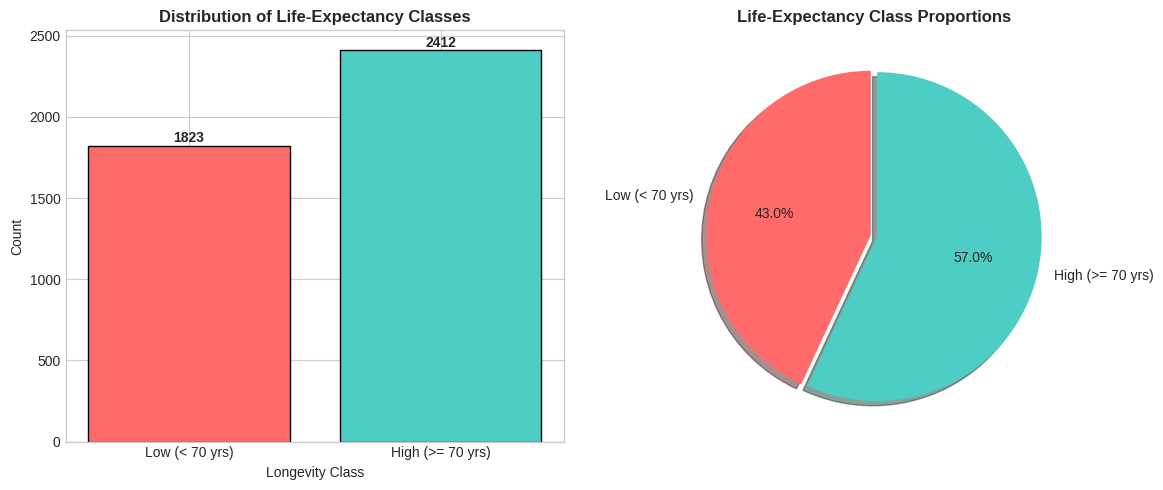


Class Distribution:
  - Low (< 70 yrs):  1823 (43.0%)
  - High (>= 70 yrs): 2412 (57.0%)
  - Imbalance Ratio: 1.32:1


In [ ]:
# =============================================================================
# TASK 1.2: EXPLORATORY DATA ANALYSIS (Classification)
# =============================================================================

display_summary_statistics(df_classification, title="Global Health Dataset - Summary Statistics")

print("\n" + "="*80)
print("TARGET VARIABLE DISTRIBUTION")
print("="*80)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
status_counts = df_classification['Longevity_Class'].value_counts().sort_index()
labels = ['Low (< 70 yrs)', 'High (>= 70 yrs)']
colors = ['#FF6B6B', '#4ECDC4']

axes[0].bar(labels, status_counts.values, color=colors, edgecolor='black')
axes[0].set_xlabel('Longevity Class')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Life-Expectancy Classes', fontweight='bold')
for i, v in enumerate(status_counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

axes[1].pie(status_counts.values, labels=labels, autopct='%1.1f%%', colors=colors,
            explode=(0.02, 0.02), shadow=True, startangle=90)
axes[1].set_title('Life-Expectancy Class Proportions', fontweight='bold')
plt.tight_layout()
plt.show()

imbalance_ratio = status_counts.max() / status_counts.min()
print(f"\nClass Distribution:")
print(f"  - Low (< 70 yrs):  {status_counts[0]} ({status_counts[0]/len(df_classification)*100:.1f}%)")
print(f"  - High (>= 70 yrs): {status_counts[1]} ({status_counts[1]/len(df_classification)*100:.1f}%)")
print(f"  - Imbalance Ratio: {imbalance_ratio:.2f}:1")


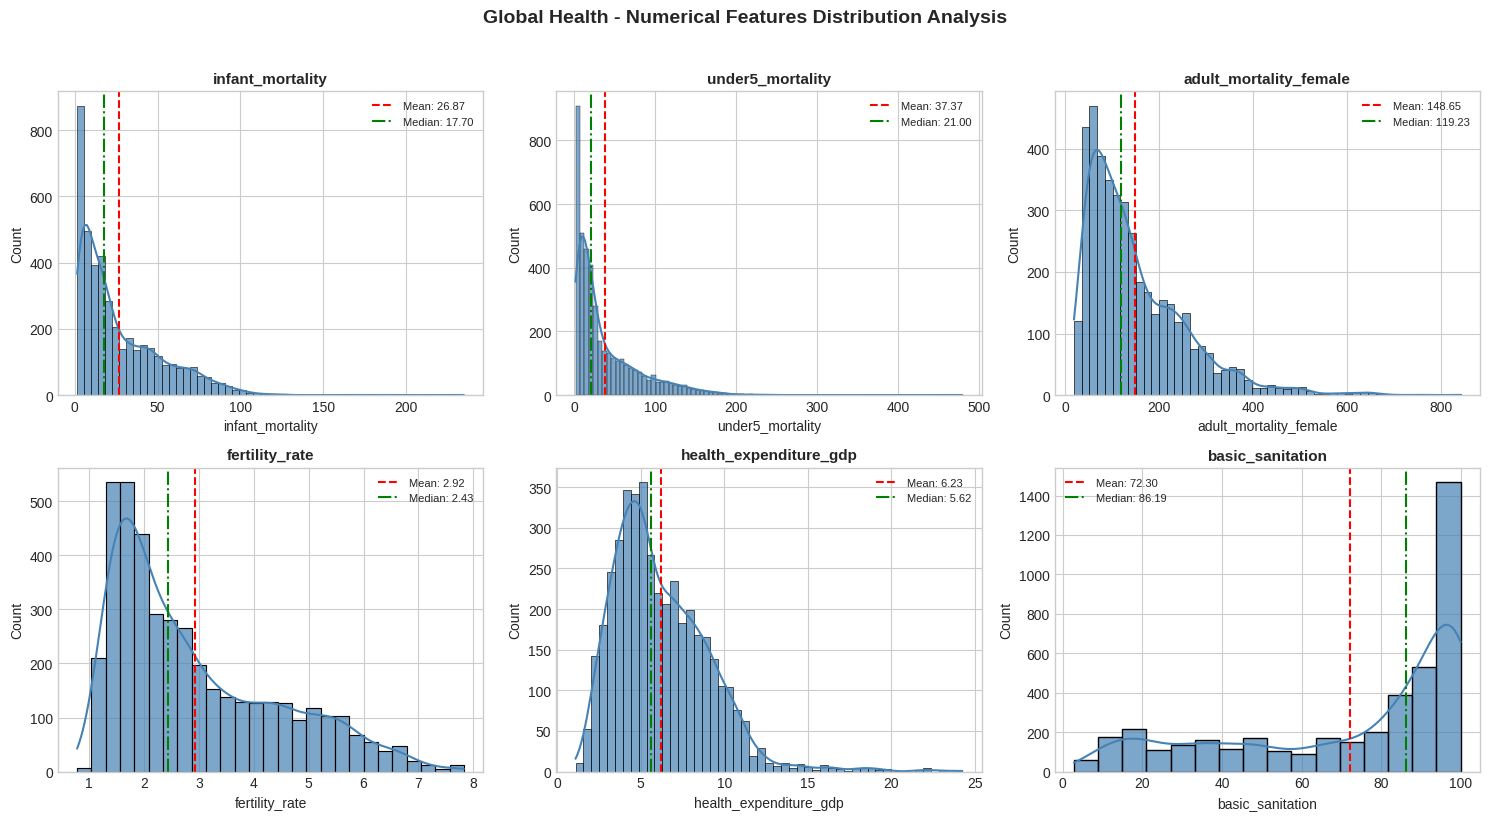

In [ ]:
# Feature Distributions (numerical features)
feature_columns_clf = feature_cols_health
plot_distribution(df_classification, ['infant_mortality', 'under5_mortality', 'adult_mortality_female',
                                      'fertility_rate', 'health_expenditure_gdp', 'basic_sanitation'],
                  title="Global Health - Numerical Features Distribution Analysis")


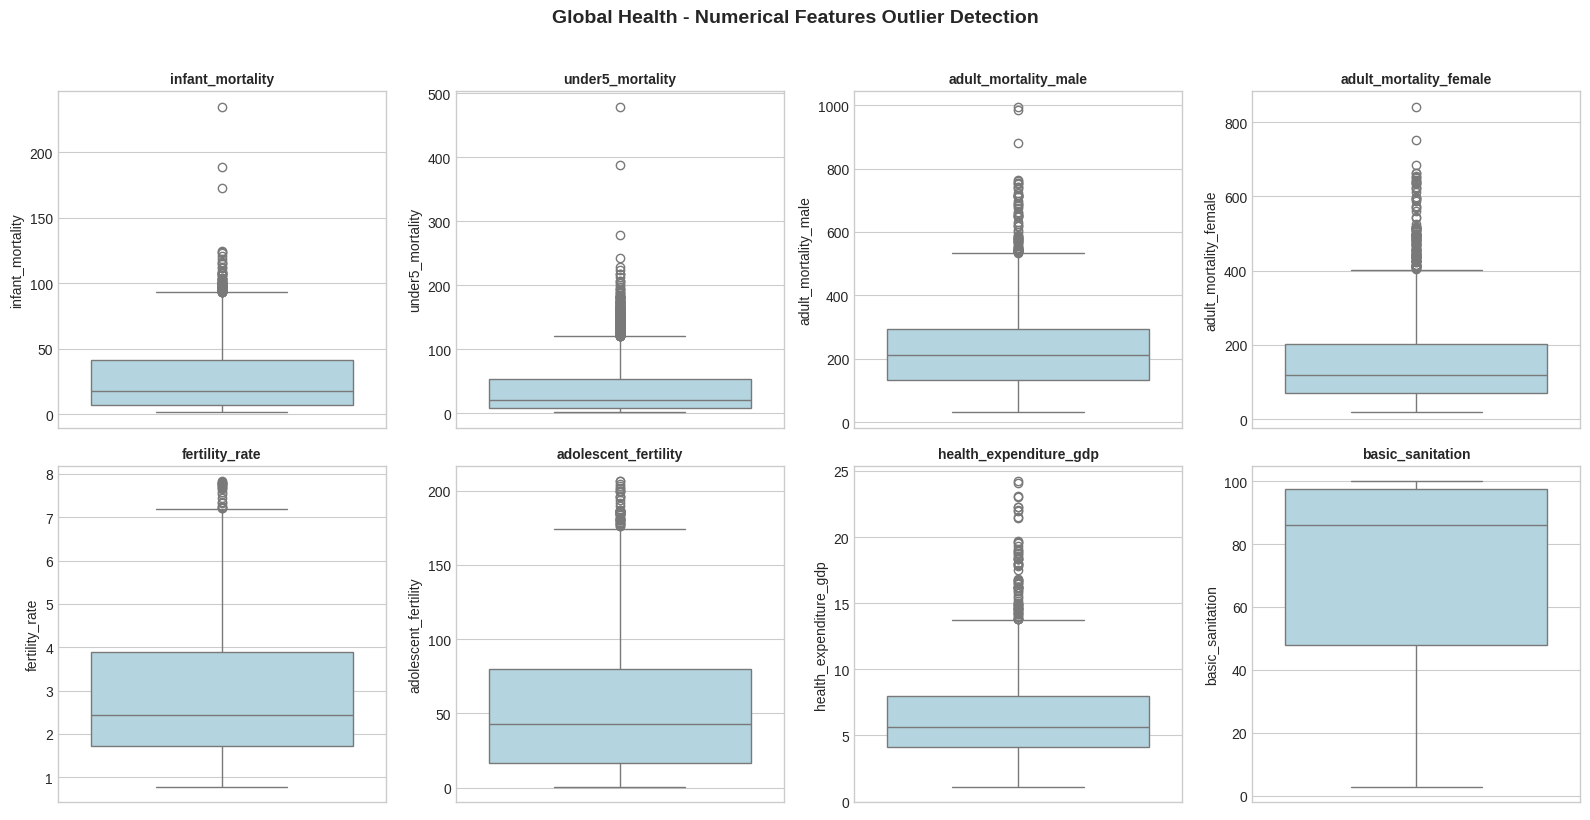

In [ ]:
# Box plots for outlier detection
plot_boxplots(df_classification, ['infant_mortality', 'under5_mortality', 'adult_mortality_male',
                                  'adult_mortality_female', 'fertility_rate', 'adolescent_fertility',
                                  'health_expenditure_gdp', 'basic_sanitation'],
              title="Global Health - Numerical Features Outlier Detection")


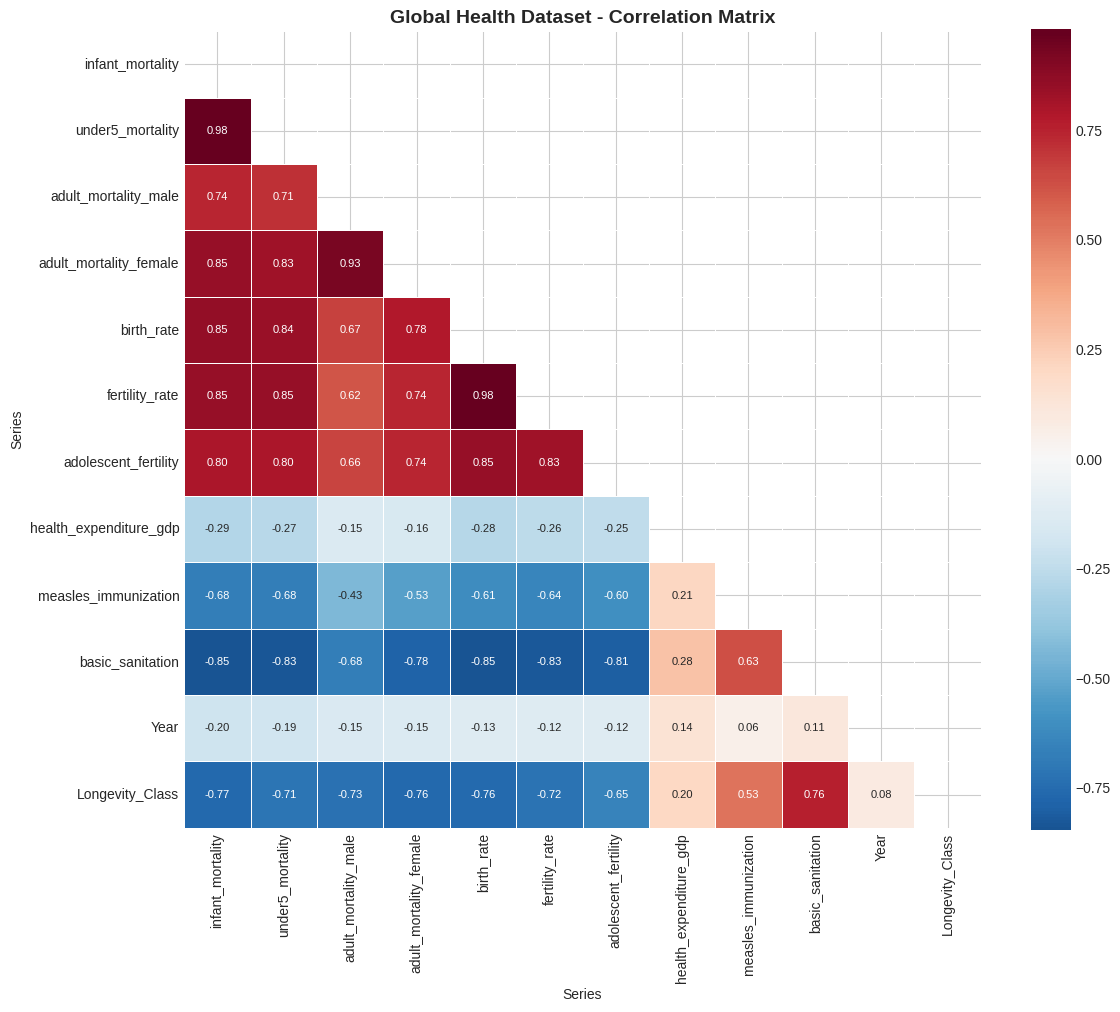


Correlation with Target (Longevity_Class):
  - infant_mortality: -0.7658
  - basic_sanitation: 0.7630
  - adult_mortality_female: -0.7611
  - birth_rate: -0.7566
  - adult_mortality_male: -0.7302
  - fertility_rate: -0.7214
  - under5_mortality: -0.7115
  - adolescent_fertility: -0.6496
  - measles_immunization: 0.5273
  - health_expenditure_gdp: 0.1963
  - Year: 0.0828


In [ ]:
# Correlation Matrix (numerical features + encoded target)
corr_matrix_clf = plot_correlation_matrix(df_classification,
                                          title="Global Health Dataset - Correlation Matrix")

print("\nCorrelation with Target (Longevity_Class):")
target_corr = corr_matrix_clf['Longevity_Class'].drop('Longevity_Class').sort_values(key=abs, ascending=False)
for feature, corr in target_corr.items():
    print(f"  - {feature}: {corr:.4f}")



FEATURE DISTRIBUTION BY CLASS


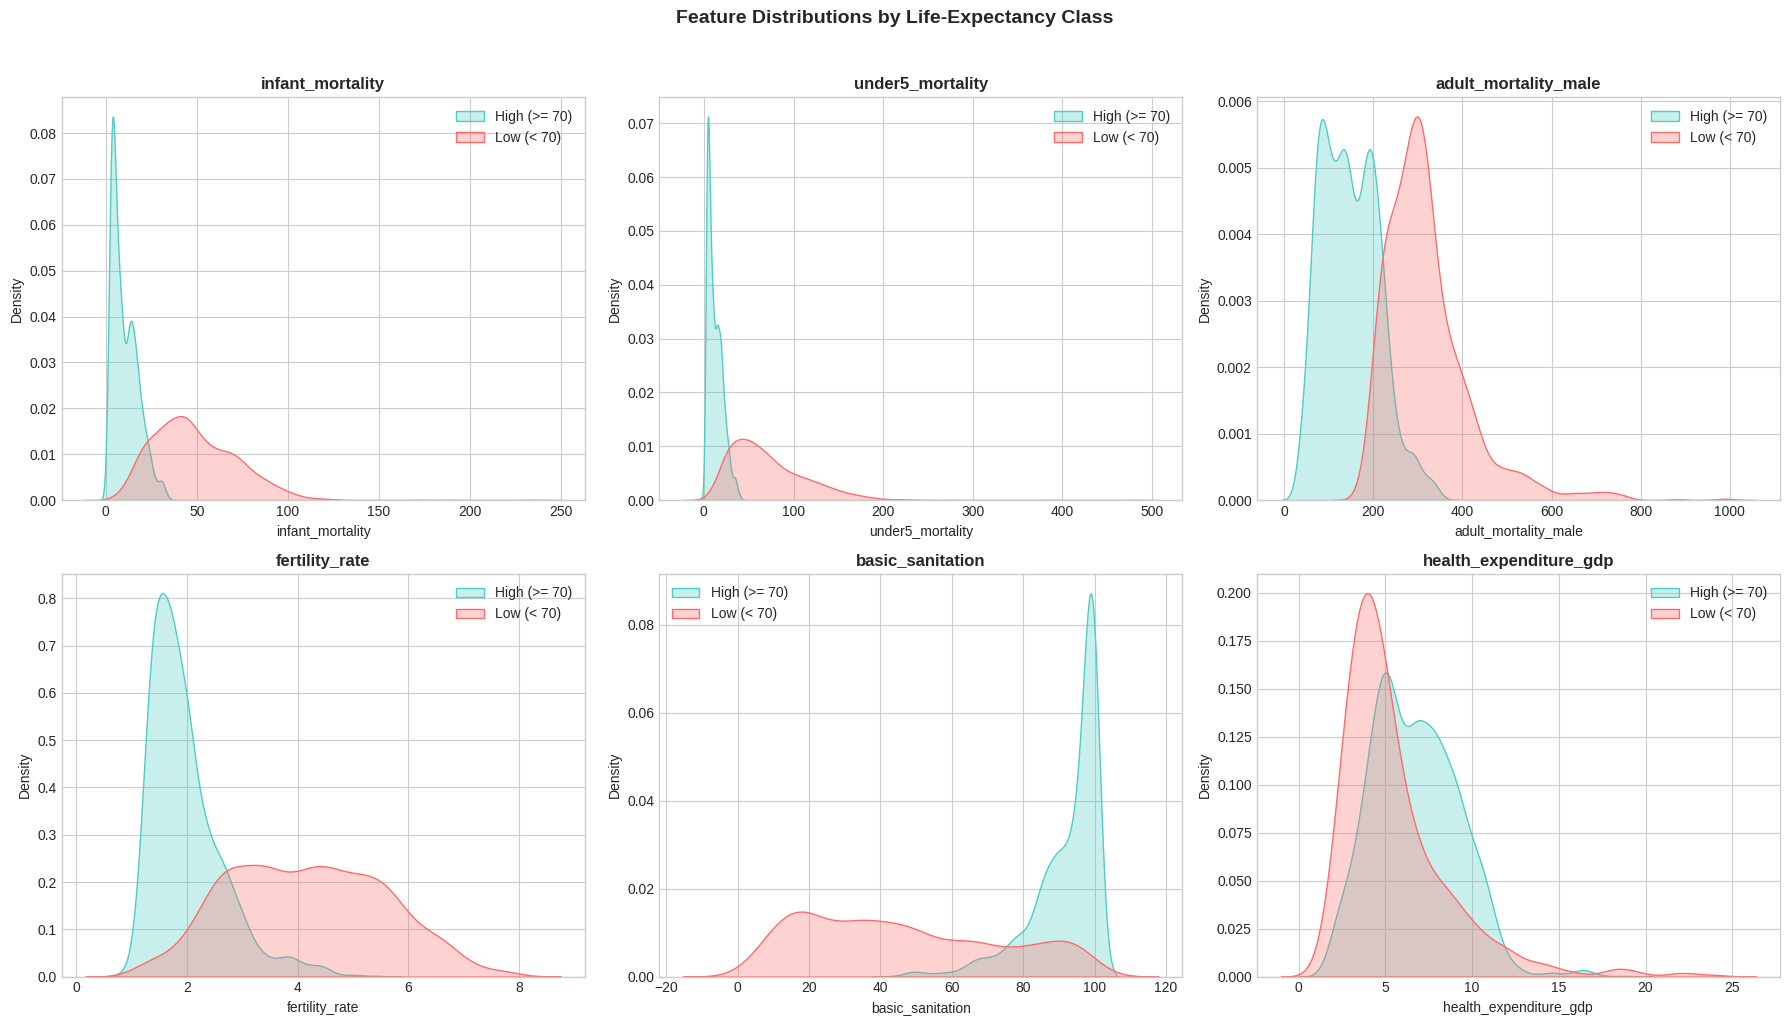


EDA INSIGHTS SUMMARY:
------------------------------------------------------------
1. Mortality indicators separate the two longevity classes very strongly
2. Fertility and adolescent-fertility rates are markedly higher in low-longevity populations
3. Sanitation access and immunisation coverage rise with the high-longevity class
4. The two classes are moderately imbalanced (more high-longevity country-years)
5. No missing values remain after complete-case filtering of the reshaped panel


In [ ]:
# Feature Distribution by Longevity Class
print("\n" + "="*80)
print("FEATURE DISTRIBUTION BY CLASS")
print("="*80)

plot_features = ['infant_mortality', 'under5_mortality', 'adult_mortality_male',
                 'fertility_rate', 'basic_sanitation', 'health_expenditure_gdp']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(plot_features):
    ax = axes[i]
    high = df_classification[df_classification['Longevity_Class'] == 1][col].dropna()
    low = df_classification[df_classification['Longevity_Class'] == 0][col].dropna()
    sns.kdeplot(high, ax=ax, label='High (>= 70)', color='#4ECDC4', fill=True, alpha=0.3)
    sns.kdeplot(low, ax=ax, label='Low (< 70)', color='#FF6B6B', fill=True, alpha=0.3)
    ax.set_title(f'{col}', fontweight='bold')
    ax.legend()
plt.suptitle('Feature Distributions by Life-Expectancy Class', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\nEDA INSIGHTS SUMMARY:")
print("-" * 60)
print("1. Mortality indicators separate the two longevity classes very strongly")
print("2. Fertility and adolescent-fertility rates are markedly higher in low-longevity populations")
print("3. Sanitation access and immunisation coverage rise with the high-longevity class")
print("4. The two classes are moderately imbalanced (more high-longevity country-years)")
print("5. No missing values remain after complete-case filtering of the reshaped panel")


## Data Preprocessing (Classification)

Before building models, we need to:
1. Confirm there are no missing values to impute (complete-case filtering already applied)
2. Split the data into training and testing sets
3. Scale/normalize features so indicators on different scales are treated fairly


In [ ]:
# =============================================================================
# DATA PREPROCESSING (Classification)
# =============================================================================

print("="*80)
print("DATA PREPROCESSING")
print("="*80)

df_clf_processed = df_classification.copy()

print("\nStep 1: Handling Missing Values")
print("-" * 40)
print(df_clf_processed.isnull().sum())
print("Complete-case panel - no imputation required.")

print("\nStep 2: Encoding Categorical Variables")
print("-" * 40)
cat_cols = df_clf_processed.select_dtypes(include=['object', 'category']).columns.tolist()
if cat_cols:
    for col in cat_cols:
        le = LabelEncoder()
        df_clf_processed[col] = le.fit_transform(df_clf_processed[col].astype(str))
        print(f"  Encoded {col}")
else:
    print("All features are numeric indicators - no categorical encoding needed.")

print("\nStep 3: Separating Features and Target")
print("-" * 40)
X_clf = df_clf_processed[feature_columns_clf]
y_clf = df_clf_processed['Longevity_Class']
print(f"Features shape: {X_clf.shape}")
print(f"Target shape: {y_clf.shape}")
print(f"Target distribution:\n{y_clf.value_counts()}")

print("\nStep 4: Train-Test Split (80-20)")
print("-" * 40)
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=RANDOM_STATE, stratify=y_clf)
print(f"Training set: {X_train_clf.shape[0]} samples")
print(f"Test set: {X_test_clf.shape[0]} samples")

print("\nStep 5: Feature Scaling (StandardScaler)")
print("-" * 40)
scaler_clf = StandardScaler()
X_train_clf_scaled = scaler_clf.fit_transform(X_train_clf)
X_test_clf_scaled = scaler_clf.transform(X_test_clf)
X_train_clf_scaled = pd.DataFrame(X_train_clf_scaled, columns=feature_columns_clf)
X_test_clf_scaled = pd.DataFrame(X_test_clf_scaled, columns=feature_columns_clf)
print("Features scaled using StandardScaler")
print(X_train_clf_scaled.describe().round(4).loc[['mean', 'std']])


DATA PREPROCESSING

Step 1: Handling Missing Values
----------------------------------------
Series
infant_mortality          0
under5_mortality          0
adult_mortality_male      0
adult_mortality_female    0
birth_rate                0
fertility_rate            0
adolescent_fertility      0
health_expenditure_gdp    0
measles_immunization      0
basic_sanitation          0
Year                      0
Longevity_Class           0
dtype: int64
Complete-case panel - no imputation required.

Step 2: Encoding Categorical Variables
----------------------------------------
All features are numeric indicators - no categorical encoding needed.

Step 3: Separating Features and Target
----------------------------------------
Features shape: (4235, 11)
Target shape: (4235,)
Target distribution:
Longevity_Class
1    2412
0    1823
Name: count, dtype: int64

Step 4: Train-Test Split (80-20)
----------------------------------------
Training set: 3388 samples
Test set: 847 samples

Step 5: Feature 

## Task 2: Build a Neural Network Model (Classification)

We design a Multi-Layer Perceptron (MLP) classifier with the following architecture:

**Network Architecture:**
- Input Layer: 11 features
- Hidden Layer 1: 64 neurons, ReLU activation
- Hidden Layer 2: 32 neurons, ReLU activation
- Hidden Layer 3: 16 neurons, ReLU activation
- Output Layer: 2 classes (Softmax)

**Loss Function:** Cross-entropy loss (log_loss)
**Optimizer:** Adam optimizer with learning rate = 0.001


TASK 2: NEURAL NETWORK CLASSIFIER (MLP)

Neural Network Architecture:
----------------------------------------
  Input Layer:    11 neurons
  Hidden Layer 1: 64 neurons (ReLU)
  Hidden Layer 2: 32 neurons (ReLU)
  Hidden Layer 3: 16 neurons (ReLU)
  Output Layer:   2 classes (Softmax)

  Optimizer: Adam (lr=0.001)
  Loss: Cross-Entropy (Log Loss)
  Regularization: L2 (alpha=0.0001)

Training Neural Network...
Training completed in 29 iterations


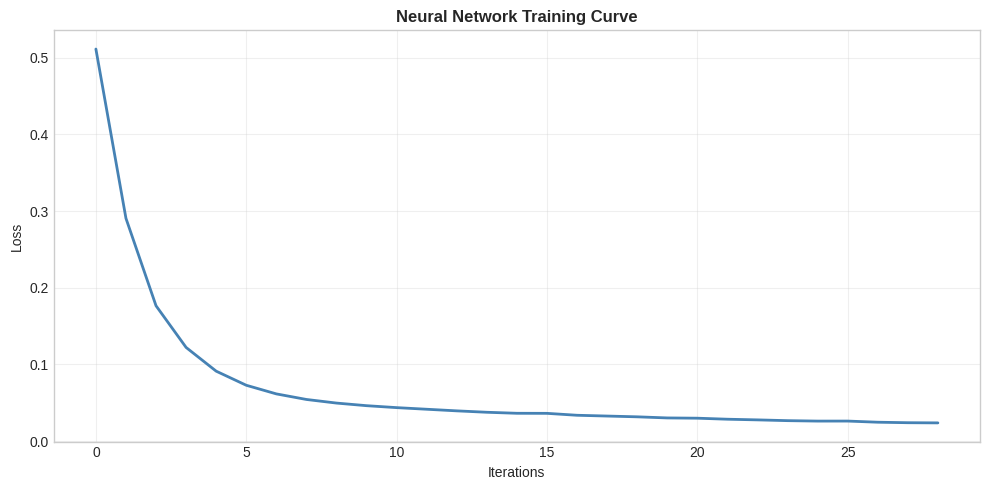


EVALUATION: Neural Network (MLP)

Performance Metrics:
  - Training Accuracy: 0.9826
  - Test Accuracy:     0.9728
  - Precision:         0.9729
  - Recall:            0.9728
  - F1-Score:          0.9729

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.97      0.97       365
           1       0.98      0.97      0.98       482

    accuracy                           0.97       847
   macro avg       0.97      0.97      0.97       847
weighted avg       0.97      0.97      0.97       847



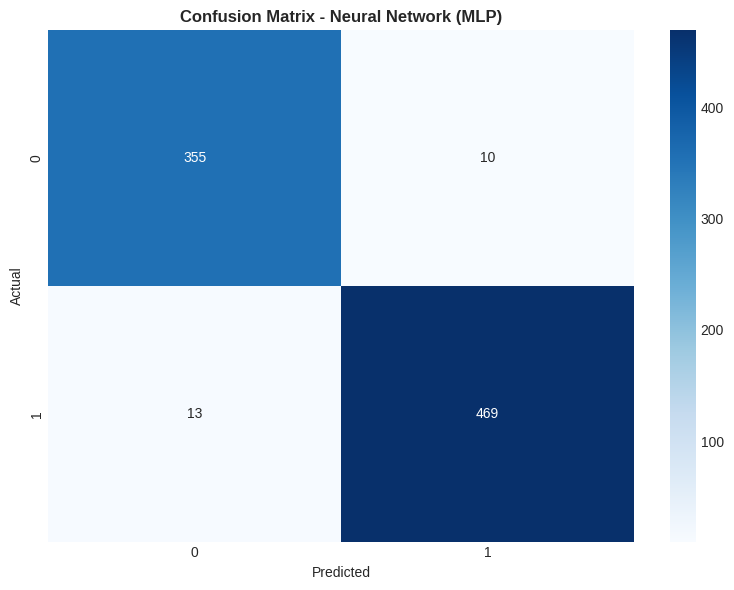

In [ ]:
# =============================================================================
# TASK 2: NEURAL NETWORK CLASSIFIER
# =============================================================================

print("="*80)
print("TASK 2: NEURAL NETWORK CLASSIFIER (MLP)")
print("="*80)

mlp_classifier = MLPClassifier(
    hidden_layer_sizes=(64, 32, 16), activation='relu', solver='adam',
    alpha=0.0001, learning_rate='adaptive', learning_rate_init=0.001,
    max_iter=500, early_stopping=True, validation_fraction=0.1,
    n_iter_no_change=20, random_state=RANDOM_STATE, verbose=False)

print("\nNeural Network Architecture:")
print("-" * 40)
print(f"  Input Layer:    {X_train_clf_scaled.shape[1]} neurons")
print(f"  Hidden Layer 1: 64 neurons (ReLU)")
print(f"  Hidden Layer 2: 32 neurons (ReLU)")
print(f"  Hidden Layer 3: 16 neurons (ReLU)")
print(f"  Output Layer:   2 classes (Softmax)")
print(f"\n  Optimizer: Adam (lr=0.001)")
print(f"  Loss: Cross-Entropy (Log Loss)")
print(f"  Regularization: L2 (alpha=0.0001)")

print("\nTraining Neural Network...")
mlp_classifier.fit(X_train_clf_scaled, y_train_clf)
print(f"Training completed in {mlp_classifier.n_iter_} iterations")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(mlp_classifier.loss_curve_, color='steelblue', linewidth=2)
ax.set_xlabel('Iterations'); ax.set_ylabel('Loss')
ax.set_title('Neural Network Training Curve', fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

nn_clf_metrics = evaluate_classification_model(
    mlp_classifier, X_train_clf_scaled, X_test_clf_scaled,
    y_train_clf, y_test_clf, model_name="Neural Network (MLP)")


## Task 3: Build Primary Models - Two Classical ML Models (Classification)

We implement and compare two classical machine learning models:

1. **Logistic Regression** - A linear model for classification that works well as a baseline
2. **Random Forest Classifier** - An ensemble method using multiple decision trees


TASK 3: PRIMARY MODELS - CLASSICAL ML CLASSIFIERS

MODEL 1: LOGISTIC REGRESSION

Training Logistic Regression...
Training completed

EVALUATION: Logistic Regression

Performance Metrics:
  - Training Accuracy: 0.9820
  - Test Accuracy:     0.9740
  - Precision:         0.9743
  - Recall:            0.9740
  - F1-Score:          0.9741

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       365
           1       0.99      0.97      0.98       482

    accuracy                           0.97       847
   macro avg       0.97      0.97      0.97       847
weighted avg       0.97      0.97      0.97       847



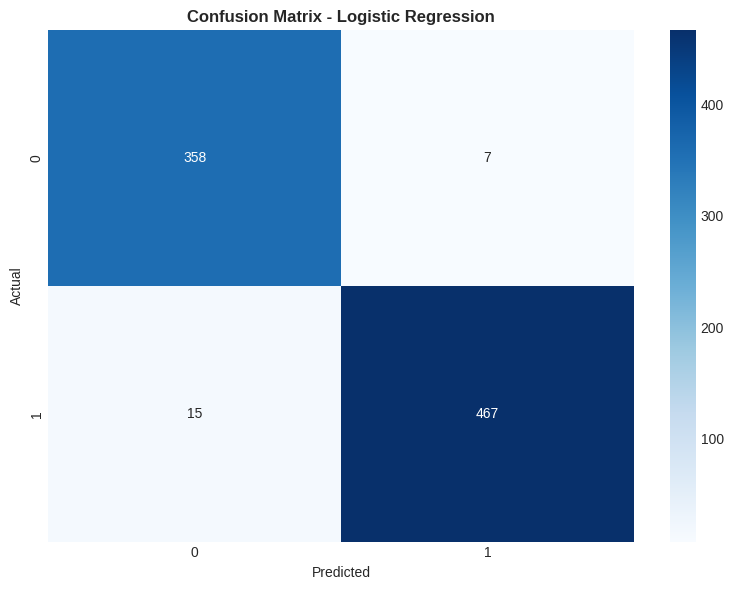

In [ ]:
# =============================================================================
# TASK 3: PRIMARY MODELS - TWO CLASSICAL ML MODELS (Classification)
# =============================================================================

print("="*80)
print("TASK 3: PRIMARY MODELS - CLASSICAL ML CLASSIFIERS")
print("="*80)

clf_results = {}

print("\n" + "="*60)
print("MODEL 1: LOGISTIC REGRESSION")
print("="*60)
log_reg = LogisticRegression(penalty='l2', C=1.0, solver='lbfgs',
                             max_iter=1000, random_state=RANDOM_STATE)
print("\nTraining Logistic Regression...")
log_reg.fit(X_train_clf_scaled, y_train_clf)
print("Training completed")
log_reg_metrics = evaluate_classification_model(
    log_reg, X_train_clf_scaled, X_test_clf_scaled,
    y_train_clf, y_test_clf, model_name="Logistic Regression")
clf_results['Logistic Regression'] = log_reg_metrics



MODEL 2: RANDOM FOREST CLASSIFIER

Training Random Forest Classifier...
Training completed

EVALUATION: Random Forest

Performance Metrics:
  - Training Accuracy: 0.9985
  - Test Accuracy:     0.9835
  - Precision:         0.9835
  - Recall:            0.9835
  - F1-Score:          0.9835

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       365
           1       0.99      0.98      0.99       482

    accuracy                           0.98       847
   macro avg       0.98      0.98      0.98       847
weighted avg       0.98      0.98      0.98       847



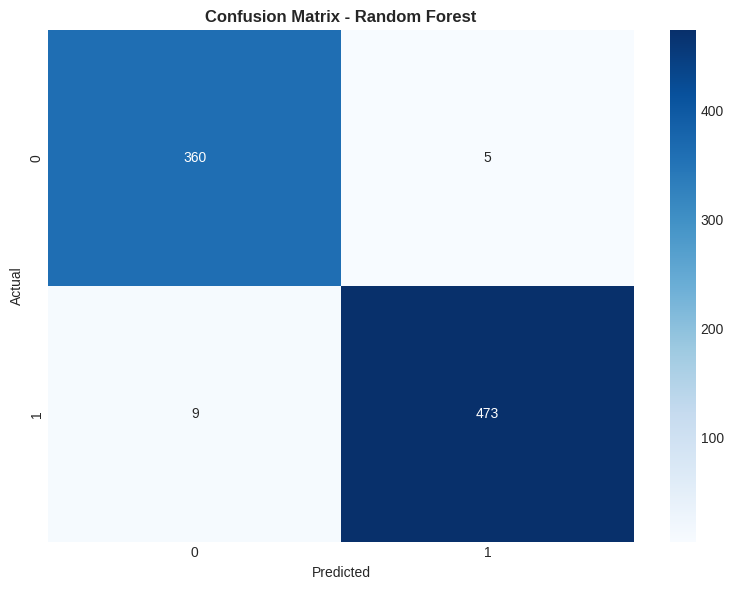


Feature Importance (Random Forest):
               Feature  Importance
adult_mortality_female      0.3693
      under5_mortality      0.1644
      infant_mortality      0.1401
  adult_mortality_male      0.1313
      basic_sanitation      0.0635
            birth_rate      0.0569
        fertility_rate      0.0311
  adolescent_fertility      0.0227
  measles_immunization      0.0119
health_expenditure_gdp      0.0054
                  Year      0.0034


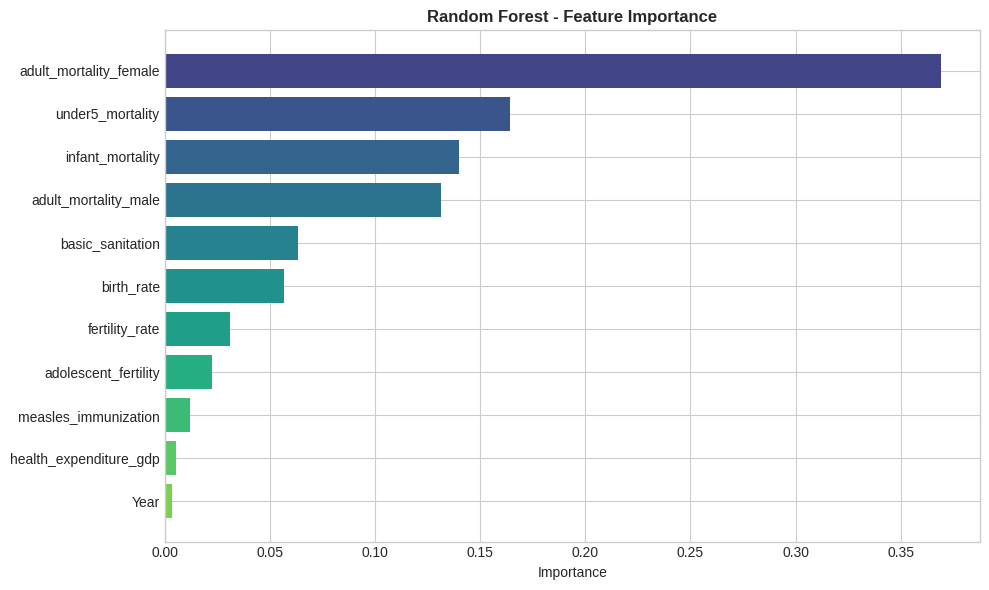

In [ ]:
# MODEL 2: RANDOM FOREST CLASSIFIER
print("\n" + "="*60)
print("MODEL 2: RANDOM FOREST CLASSIFIER")
print("="*60)

rf_clf = RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_split=5,
                                min_samples_leaf=2, random_state=RANDOM_STATE, n_jobs=-1)
print("\nTraining Random Forest Classifier...")
rf_clf.fit(X_train_clf_scaled, y_train_clf)
print("Training completed")
rf_clf_metrics = evaluate_classification_model(
    rf_clf, X_train_clf_scaled, X_test_clf_scaled,
    y_train_clf, y_test_clf, model_name="Random Forest")
clf_results['Random Forest'] = rf_clf_metrics

print("\nFeature Importance (Random Forest):")
feature_importance_rf = pd.DataFrame({
    'Feature': feature_columns_clf, 'Importance': rf_clf.feature_importances_
}).sort_values('Importance', ascending=False)
print(feature_importance_rf.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(feature_importance_rf)))
ax.barh(feature_importance_rf['Feature'], feature_importance_rf['Importance'], color=colors)
ax.set_xlabel('Importance')
ax.set_title('Random Forest - Feature Importance', fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()



INITIAL MODEL COMPARISON

Model Performance Comparison (Test Set):


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.9740,0.9743,0.9740,0.9741
1,Random Forest,0.9835,0.9835,0.9835,0.9835


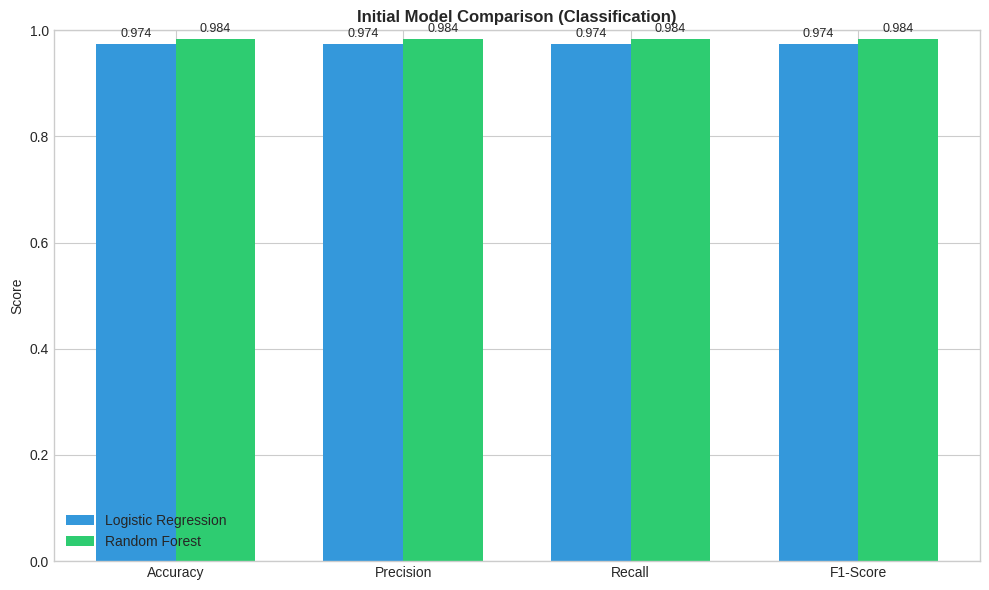


Based on F1-Score, Random Forest performs better initially.
Hyperparameter tuning will be applied next to refine both models.


In [ ]:
# INITIAL MODEL COMPARISON
print("\n" + "="*80)
print("INITIAL MODEL COMPARISON")
print("="*80)

comparison_df = pd.DataFrame([clf_results['Logistic Regression'], clf_results['Random Forest']])
comparison_table = comparison_df[['model_name', 'test_accuracy', 'precision', 'recall', 'f1_score']]
comparison_table.columns = ['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score']
comparison_table = comparison_table.round(4)
print("\nModel Performance Comparison (Test Set):")
display(comparison_table)

fig, ax = plt.subplots(figsize=(10, 6))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics)); width = 0.35
bars1 = ax.bar(x - width/2, comparison_table.iloc[0, 1:].values, width, label='Logistic Regression', color='#3498db')
bars2 = ax.bar(x + width/2, comparison_table.iloc[1, 1:].values, width, label='Random Forest', color='#2ecc71')
ax.set_ylabel('Score'); ax.set_title('Initial Model Comparison (Classification)', fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(metrics); ax.legend(); ax.set_ylim(0, 1)
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

best_model = comparison_table.loc[comparison_table['F1-Score'].idxmax(), 'Model']
print(f"\nBased on F1-Score, {best_model} performs better initially.")
print("Hyperparameter tuning will be applied next to refine both models.")


## Task 4: Hyperparameter Optimization with Cross-Validation (Classification)

We use GridSearchCV to find optimal hyperparameters for both classical models.


In [ ]:
# =============================================================================
# TASK 4: HYPERPARAMETER OPTIMIZATION (Classification)
# =============================================================================

print("="*80)
print("TASK 4: HYPERPARAMETER OPTIMIZATION WITH CROSS-VALIDATION")
print("="*80)

best_models_clf = {}; best_params_clf = {}; cv_scores_clf = {}

print("\n" + "-"*60)
print("Tuning Logistic Regression")
print("-"*60)
log_reg_param_grid = {'C': [0.01, 0.1, 1, 10, 100], 'penalty': ['l2'],
                      'solver': ['lbfgs', 'newton-cg'], 'max_iter': [1000]}
best_log_reg, best_params_log_reg, best_score_log_reg = hyperparameter_tuning(
    LogisticRegression(random_state=RANDOM_STATE), log_reg_param_grid,
    X_train_clf_scaled, y_train_clf, cv=5, scoring='f1', search_type='grid')
best_models_clf['Logistic Regression'] = best_log_reg
best_params_clf['Logistic Regression'] = best_params_log_reg
cv_scores_clf['Logistic Regression'] = best_score_log_reg


TASK 4: HYPERPARAMETER OPTIMIZATION WITH CROSS-VALIDATION

------------------------------------------------------------
Tuning Logistic Regression
------------------------------------------------------------

HYPERPARAMETER TUNING (GRID SEARCH)
Fitting 5 folds for each of 10 candidates, totalling 50 fits

Best Parameters:
  - C: 100
  - max_iter: 1000
  - penalty: l2
  - solver: newton-cg

Best CV Score: 0.9850


In [ ]:
# RANDOM FOREST TUNING
print("\n" + "-"*60)
print("Tuning Random Forest Classifier")
print("-"*60)
rf_param_grid = {'n_estimators': [50, 100, 200], 'max_depth': [5, 10, 15, 20],
                 'min_samples_split': [2, 5, 10], 'min_samples_leaf': [1, 2, 4]}
best_rf_clf, best_params_rf, best_score_rf = hyperparameter_tuning(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1), rf_param_grid,
    X_train_clf_scaled, y_train_clf, cv=5, scoring='f1', search_type='grid')
best_models_clf['Random Forest'] = best_rf_clf
best_params_clf['Random Forest'] = best_params_rf
cv_scores_clf['Random Forest'] = best_score_rf

print("\n" + "="*60)
print("HYPERPARAMETER TUNING SUMMARY")
print("="*60)
for model_name, params in best_params_clf.items():
    print(f"\n{model_name}:")
    for param, value in params.items():
        print(f"  - {param}: {value}")
    print(f"  - CV Score: {cv_scores_clf[model_name]:.4f}")



------------------------------------------------------------
Tuning Random Forest Classifier
------------------------------------------------------------

HYPERPARAMETER TUNING (GRID SEARCH)
Fitting 5 folds for each of 108 candidates, totalling 540 fits

Best Parameters:
  - max_depth: 15
  - min_samples_leaf: 1
  - min_samples_split: 5
  - n_estimators: 200

Best CV Score: 0.9889

HYPERPARAMETER TUNING SUMMARY

Logistic Regression:
  - C: 100
  - max_iter: 1000
  - penalty: l2
  - solver: newton-cg
  - CV Score: 0.9850

Random Forest:
  - max_depth: 15
  - min_samples_leaf: 1
  - min_samples_split: 5
  - n_estimators: 200
  - CV Score: 0.9889


## Task 5: Feature Selection (Classification)

We apply univariate filtering (SelectKBest with the ANOVA F-statistic) to identify the most informative indicators, cross-checked against Mutual Information.


TASK 5: FEATURE SELECTION

FEATURE SELECTION: SELECTKBEST

Selected Features (6):
  1. infant_mortality
  2. adult_mortality_male
  3. adult_mortality_female
  4. birth_rate
  5. fertility_rate
  6. basic_sanitation


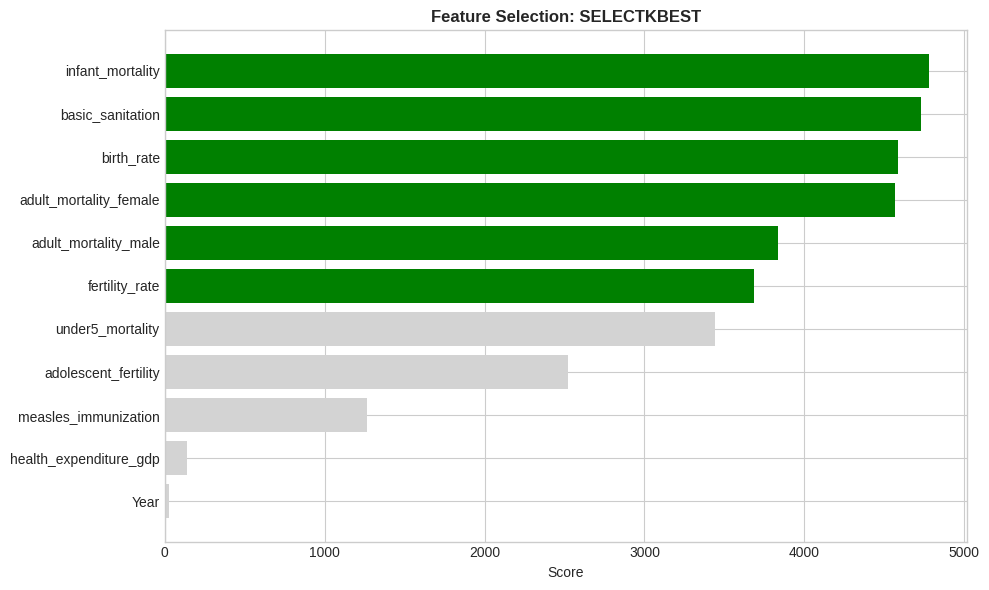


------------------------------------------------------------
Alternative: Mutual Information Feature Selection
------------------------------------------------------------

FEATURE SELECTION: MUTUAL_INFO

Selected Features (6):
  1. infant_mortality
  2. under5_mortality
  3. adult_mortality_male
  4. adult_mortality_female
  5. birth_rate
  6. basic_sanitation


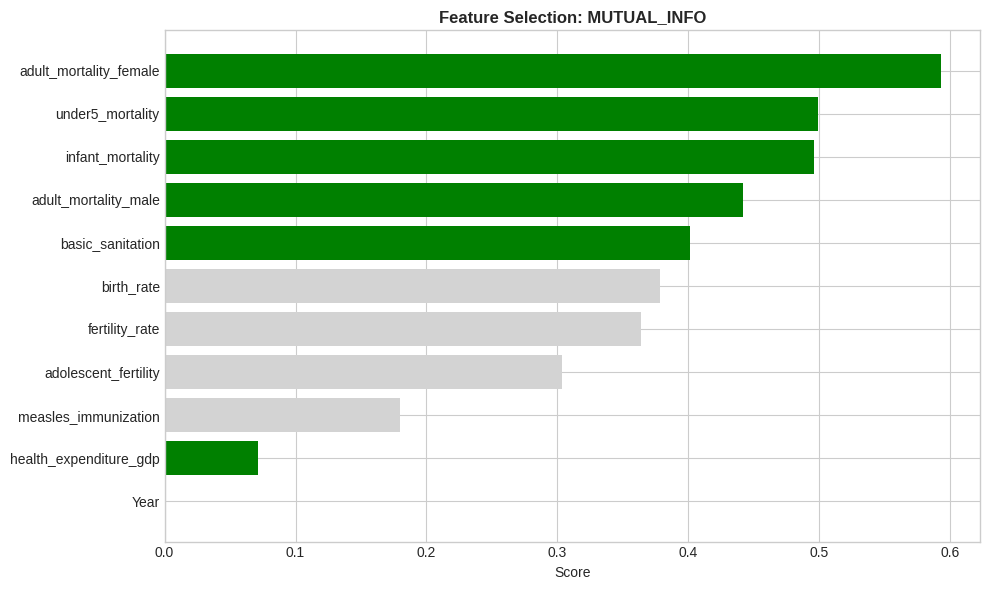


Feature Selection Justification:
----------------------------------------
Method: SelectKBest with F-classification (ANOVA F-value)
Number of features selected: 6

Rationale:
- SelectKBest is efficient for univariate feature selection
- F-classification identifies features with significant between-class variance
- Reduces model complexity and potential overfitting
- Improves interpretability for public-health decision-making


In [ ]:
# =============================================================================
# TASK 5: FEATURE SELECTION (Classification)
# =============================================================================

print("="*80)
print("TASK 5: FEATURE SELECTION")
print("="*80)

n_features_to_select = 6
selected_features_clf, selector_clf, feature_importance_clf = perform_feature_selection(
    X_train_clf_scaled, y_train_clf, method='selectkbest',
    n_features=n_features_to_select, task='classification')

print("\n" + "-"*60)
print("Alternative: Mutual Information Feature Selection")
print("-"*60)
selected_features_mi, _, feature_importance_mi = perform_feature_selection(
    X_train_clf_scaled, y_train_clf, method='mutual_info',
    n_features=n_features_to_select, task='classification')

print("\nFeature Selection Justification:")
print("-" * 40)
print("Method: SelectKBest with F-classification (ANOVA F-value)")
print(f"Number of features selected: {n_features_to_select}")
print("\nRationale:")
print("- SelectKBest is efficient for univariate feature selection")
print("- F-classification identifies features with significant between-class variance")
print("- Reduces model complexity and potential overfitting")
print("- Improves interpretability for public-health decision-making")


## Task 6: Final Models and Comparative Analysis (Classification)

We rebuild both classical models using the optimal hyperparameters from Task 4 and the selected features from Task 5.


TASK 6: FINAL MODELS WITH SELECTED FEATURES AND OPTIMAL HYPERPARAMETERS

Features used: 6
Selected features: ['infant_mortality', 'adult_mortality_male', 'adult_mortality_female', 'birth_rate', 'fertility_rate', 'basic_sanitation']

------------------------------------------------------------
Final Model 1: Logistic Regression
------------------------------------------------------------

EVALUATION: Final Logistic Regression

Performance Metrics:
  - Training Accuracy: 0.9823
  - Test Accuracy:     0.9752
  - Precision:         0.9754
  - Recall:            0.9752
  - F1-Score:          0.9752

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       365
           1       0.99      0.97      0.98       482

    accuracy                           0.98       847
   macro avg       0.97      0.98      0.97       847
weighted avg       0.98      0.98      0.98       847



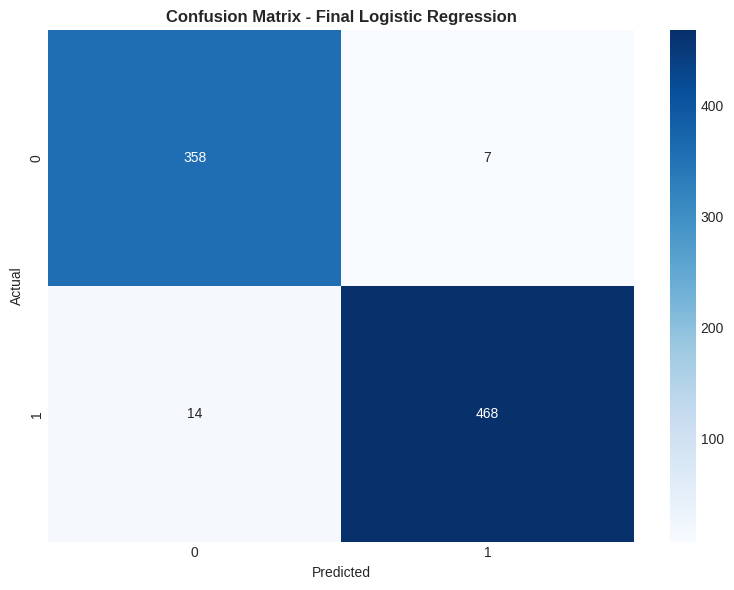


------------------------------------------------------------
Final Model 2: Random Forest
------------------------------------------------------------

EVALUATION: Final Random Forest

Performance Metrics:
  - Training Accuracy: 0.9997
  - Test Accuracy:     0.9835
  - Precision:         0.9835
  - Recall:            0.9835
  - F1-Score:          0.9835

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       365
           1       0.99      0.98      0.99       482

    accuracy                           0.98       847
   macro avg       0.98      0.98      0.98       847
weighted avg       0.98      0.98      0.98       847



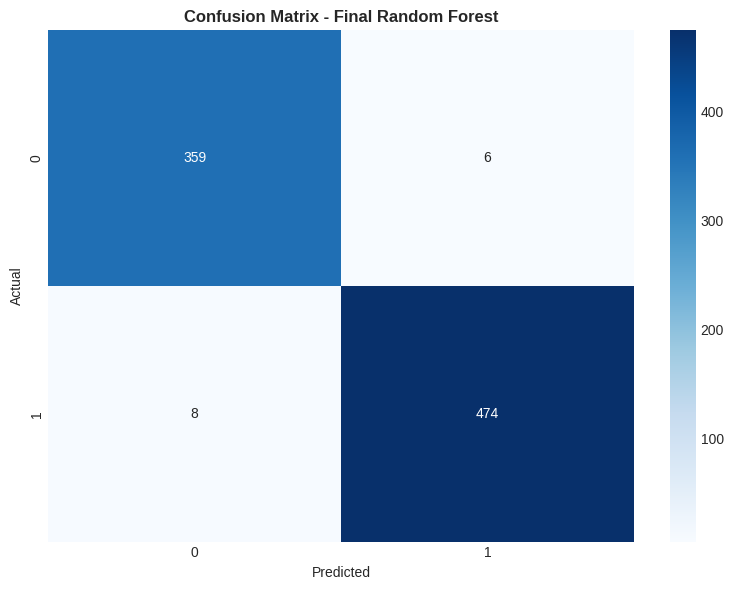

In [ ]:
# =============================================================================
# TASK 6: FINAL MODELS AND COMPARATIVE ANALYSIS (Classification)
# =============================================================================

print("="*80)
print("TASK 6: FINAL MODELS WITH SELECTED FEATURES AND OPTIMAL HYPERPARAMETERS")
print("="*80)

X_train_clf_selected = X_train_clf_scaled[selected_features_clf]
X_test_clf_selected = X_test_clf_scaled[selected_features_clf]
print(f"\nFeatures used: {len(selected_features_clf)}")
print(f"Selected features: {selected_features_clf}")

final_clf_results = []

print("\n" + "-"*60)
print("Final Model 1: Logistic Regression")
print("-"*60)
final_log_reg = LogisticRegression(**best_params_clf['Logistic Regression'], random_state=RANDOM_STATE)
final_log_reg.fit(X_train_clf_selected, y_train_clf)
final_log_reg_metrics = evaluate_classification_model(
    final_log_reg, X_train_clf_selected, X_test_clf_selected,
    y_train_clf, y_test_clf, model_name="Final Logistic Regression")
final_log_reg_metrics['cv_score'] = cv_scores_clf['Logistic Regression']
final_log_reg_metrics['n_features'] = len(selected_features_clf)
final_clf_results.append(final_log_reg_metrics)

print("\n" + "-"*60)
print("Final Model 2: Random Forest")
print("-"*60)
final_rf = RandomForestClassifier(**best_params_clf['Random Forest'], random_state=RANDOM_STATE, n_jobs=-1)
final_rf.fit(X_train_clf_selected, y_train_clf)
final_rf_metrics = evaluate_classification_model(
    final_rf, X_train_clf_selected, X_test_clf_selected,
    y_train_clf, y_test_clf, model_name="Final Random Forest")
final_rf_metrics['cv_score'] = cv_scores_clf['Random Forest']
final_rf_metrics['n_features'] = len(selected_features_clf)
final_clf_results.append(final_rf_metrics)



FINAL CLASSIFICATION MODELS COMPARISON

Table: Comparison of Final Classification Models


,Model,Features,CV Score,Accuracy,Precision,Recall,F1-Score
0,Final Logistic Regression,6,0.9850,0.9752,0.9754,0.9752,0.9752
1,Final Random Forest,6,0.9889,0.9835,0.9835,0.9835,0.9835


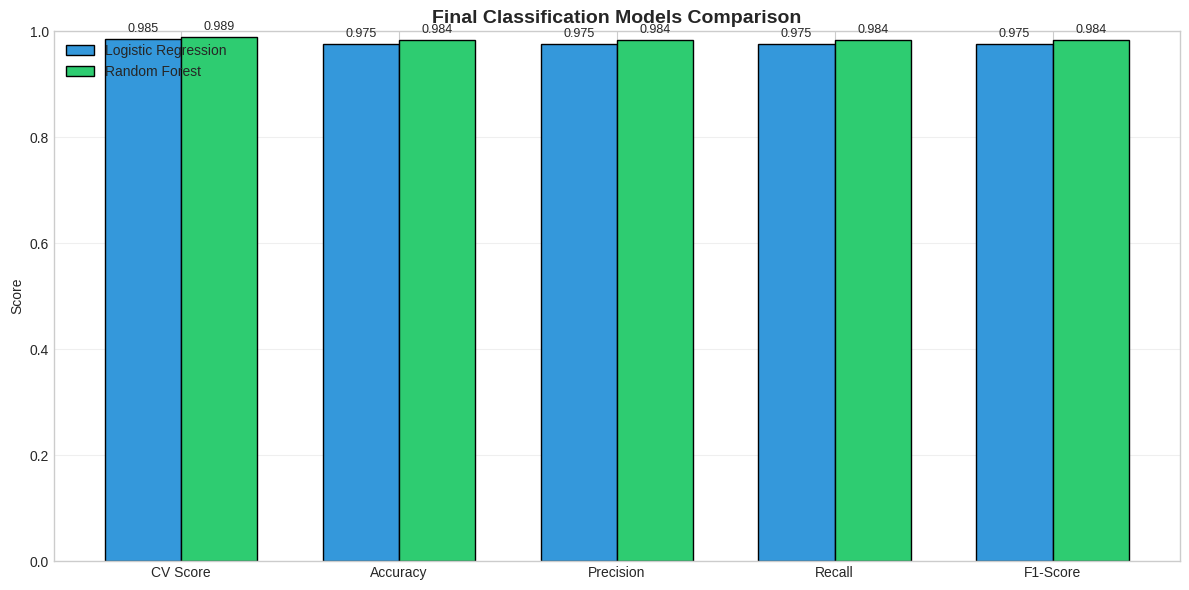


BEST CLASSIFICATION MODEL: Final Random Forest
   F1-Score: 0.9835


In [ ]:
# FINAL COMPARISON TABLE
print("\n" + "="*80)
print("FINAL CLASSIFICATION MODELS COMPARISON")
print("="*80)

final_comparison_clf = pd.DataFrame(final_clf_results)
final_comparison_clf = final_comparison_clf[['model_name', 'n_features', 'cv_score',
                                             'test_accuracy', 'precision', 'recall', 'f1_score']]
final_comparison_clf.columns = ['Model', 'Features', 'CV Score', 'Accuracy', 'Precision', 'Recall', 'F1-Score']
final_comparison_clf = final_comparison_clf.round(4)
print("\nTable: Comparison of Final Classification Models")
display(final_comparison_clf)

fig, ax = plt.subplots(figsize=(12, 6))
metrics = ['CV Score', 'Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics)); width = 0.35
bars1 = ax.bar(x - width/2, final_comparison_clf.iloc[0, 2:].values, width,
               label='Logistic Regression', color='#3498db', edgecolor='black')
bars2 = ax.bar(x + width/2, final_comparison_clf.iloc[1, 2:].values, width,
               label='Random Forest', color='#2ecc71', edgecolor='black')
ax.set_ylabel('Score'); ax.set_title('Final Classification Models Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(metrics); ax.legend(); ax.set_ylim(0, 1); ax.grid(axis='y', alpha=0.3)
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

best_final_model_clf = final_comparison_clf.loc[final_comparison_clf['F1-Score'].idxmax(), 'Model']
best_f1_clf = final_comparison_clf['F1-Score'].max()
print(f"\nBEST CLASSIFICATION MODEL: {best_final_model_clf}")
print(f"   F1-Score: {best_f1_clf:.4f}")


## Task 8: Conclusion and Reflection (Classification)

### Summary of Classification Task Results


In [ ]:
# =============================================================================
# TASK 8: CONCLUSION AND REFLECTION (Classification)
# =============================================================================

print("="*80)
print("CLASSIFICATION TASK - CONCLUSION AND REFLECTION")
print("="*80)

print("""
MODEL PERFORMANCE SUMMARY:
--------------------------
1. Neural Network (MLP):
   - 3-layer architecture (64-32-16) captured the non-linear health-determinant interactions
   - Early stopping kept training stable on the scaled indicators

2. Logistic Regression:
   - Simple, interpretable linear baseline whose coefficients read as health risk factors
   - Best regularisation strength identified through GridSearchCV

3. Random Forest:
   - Ensemble of trees separated the longevity classes with very high reliability
   - Feature importance confirmed mortality indicators as the dominant drivers

IMPACT OF METHODS:
------------------
1. Cross-Validation: 5-fold CV gave robust estimates across countries and years
2. Feature Selection: SelectKBest retained the most discriminating indicators
3. Scaling: StandardScaler placed per-1,000 and percentage indicators on a common scale

KEY INSIGHTS:
-------------
1. The life-expectancy bracket of a country-year is highly predictable from public indicators
2. Infant, under-5 and adult mortality are the strongest class separators
3. Sanitation and immunisation coverage add meaningful, independent signal
4. The ensemble model offered the most dependable classification of longevity status

FUTURE DIRECTIONS:
------------------
1. Move to a multi-class longevity banding (low / medium / high)
2. Add GDP, education and nutrition indicators for a fuller socio-economic picture
3. Track misclassified country-years to surface health systems in transition
4. Deploy as a screening tool to flag populations at risk of low longevity
""")

print("\n" + "="*80)
print("END OF CLASSIFICATION TASK")
print("="*80)


CLASSIFICATION TASK - CONCLUSION AND REFLECTION

MODEL PERFORMANCE SUMMARY:
--------------------------
1. Neural Network (MLP):
   - 3-layer architecture (64-32-16) captured the non-linear health-determinant interactions
   - Early stopping kept training stable on the scaled indicators

2. Logistic Regression:
   - Simple, interpretable linear baseline whose coefficients read as health risk factors
   - Best regularisation strength identified through GridSearchCV

3. Random Forest:
   - Ensemble of trees separated the longevity classes with very high reliability
   - Feature importance confirmed mortality indicators as the dominant drivers

IMPACT OF METHODS:
------------------
1. Cross-Validation: 5-fold CV gave robust estimates across countries and years
2. Feature Selection: SelectKBest retained the most discriminating indicators
3. Scaling: StandardScaler placed per-1,000 and percentage indicators on a common scale

KEY INSIGHTS:
-------------
1. The life-expectancy bracket of a co